# 06 - LLM Report Teacher Schema and Validation

This notebook prepares reports for external LLM labelling and validates an uploaded `report_weak_labels.csv` using the final schema:

```text
Present / Absent / Uncertain / Not Mentioned
+ weak label
+ confidence
+ evidence
```

It does not call an LLM inside Kaggle. The LLM CSV is created outside Kaggle and uploaded as a Kaggle Dataset.

**Outputs:**
- `/kaggle/working/reports_for_llm.csv`
- `/kaggle/working/report_weak_labels_clean.csv`
- `/kaggle/working/report_teacher_validation.csv`
- `/kaggle/working/report_teacher_coverage.csv`

In [10]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
WORK_DIR = "/kaggle/working"

train = pd.read_csv(DATA_DIR + "/train.csv")

label_cols = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

gold_train = train.dropna(subset=label_cols).copy().reset_index(drop=True)
report_only_train = train[train[label_cols].isna().any(axis=1)].copy().reset_index(drop=True)

print("Total train studies:", len(train))
print("Complete gold-labelled studies:", len(gold_train))
print("Report-only/incomplete studies:", len(report_only_train))

Total train studies: 4407
Complete gold-labelled studies: 58
Report-only/incomplete studies: 4349


In [11]:
# Export all reports for external LLM labelling.
# For a fast smoke test, you may temporarily use head(500), but final report-teacher generation should use all train reports.

USE_SMOKE_TEST = False
SMOKE_TEST_N = 500

reports_for_llm = train[["StudyInstanceUID", "Report"]].copy()
reports_for_llm["Report"] = reports_for_llm["Report"].fillna("").astype(str)

if USE_SMOKE_TEST:
    reports_for_llm = reports_for_llm.head(SMOKE_TEST_N).copy()

reports_path = WORK_DIR + "/reports_for_llm.csv"
reports_for_llm.to_csv(reports_path, index=False)

print("Saved reports for external LLM labelling:", reports_path)
print("Rows:", len(reports_for_llm))
display(reports_for_llm.head())

Saved reports for external LLM labelling: /kaggle/working/reports_for_llm.csv
Rows: 4407


,StudyInstanceUID,Report
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no..."
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...


## External LLM Prompt

Use this prompt outside Kaggle with Gemini/Groq/OpenRouter/another LLM. Return JSON/CSV fields matching the schema below.

```text
You are a medical report label extraction assistant.

Task:
Extract structured multi-label findings from a knee MRI radiology report.

Findings:
ACL, MCL, Medial Meniscus, Lateral Meniscus, Medial OA, Lateral OA, PF OA, Effusion, Synovitis, Baker's, Contusion, Fracture

For each finding return:
status: one of Present, Absent, Uncertain, Not Mentioned
label: 1 if Present, 0 if Absent, null if Uncertain or Not Mentioned
confidence: number from 0 to 1
evidence: exact short phrase from the report, or empty string if Not Mentioned

Important:
- Do not infer beyond the report.
- Respect negation: "ACL intact" means status = Absent and label = 0.
- "No fracture" means status = Absent and label = 0.
- If the report suggests but does not confirm a finding, use status = Uncertain.
- If the finding is not discussed, use status = Not Mentioned.
- Return JSON only.

Report:
<REPORT_TEXT>
```

Final CSV columns must be:

```text
StudyInstanceUID,
ACL_status,ACL_weak,ACL_confidence,ACL_evidence,
MCL_status,MCL_weak,MCL_confidence,MCL_evidence,
...
Fracture_status,Fracture_weak,Fracture_confidence,Fracture_evidence
```

In [13]:
# Auto-detect uploaded LLM-generated report_weak_labels.csv.

weak_label_path = None

for root, dirs, files in os.walk("/kaggle/input"):
    if "report_weak_labels.csv" in files:
        weak_label_path = os.path.join(root, "report_weak_labels.csv")
        break

print("Detected weak label file:", weak_label_path)

if weak_label_path is None:
    raise FileNotFoundError(
        "report_weak_labels.csv not found. Upload the LLM-generated CSV as a Kaggle Dataset and add it as input."
    )

weak_labels_raw = pd.read_csv(weak_label_path)
print("Weak labels shape:", weak_labels_raw.shape)
display(weak_labels_raw.head())

Detected weak label file: /kaggle/input/datasets/shambhavisinha254/report-weak-labels/report_weak_labels.csv
Weak labels shape: (4407, 49)


,StudyInstanceUID,ACL_status,ACL_weak,ACL_confidence,ACL_evidence,MCL_status,MCL_weak,MCL_confidence,MCL_evidence,Medial Meniscus_status,...,Baker's_confidence,Baker's_evidence,Contusion_status,Contusion_weak,Contusion_confidence,Contusion_evidence,Fracture_status,Fracture_weak,Fracture_confidence,Fracture_evidence
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Not Mentioned,NaN,0.00,NaN,Not Mentioned,NaN,0.00,NaN,Not Mentioned,...,0.0,NaN,Not Mentioned,NaN,0.00,NaN,Not Mentioned,NaN,0.00,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,Not Mentioned,NaN,0.00,NaN,Not Mentioned,NaN,0.00,NaN,Not Mentioned,...,0.0,NaN,Not Mentioned,NaN,0.00,NaN,Not Mentioned,NaN,0.00,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Absent,0.0,0.98,Ligamentos cruzados y colaterales dentro de lí...,Not Mentioned,NaN,0.00,NaN,Not Mentioned,...,0.0,NaN,Not Mentioned,NaN,0.00,NaN,Not Mentioned,NaN,0.00,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,Absent,0.0,0.98,"ntercondylar notch, the anterior and posterior...",Absent,0.0,0.98,The medial collateral ligament complexes are i...,Not Mentioned,...,0.0,NaN,Absent,0.0,0.98,There is no fracture or bone contusion.,Absent,0.0,0.98,There is no fracture or bone contusion.
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,Absent,0.0,0.98,Ligament croisé antérieur : Normal.,Present,1.0,0.98,Entorse ancienne de bas grade du ligament coll...,Not Mentioned,...,0.0,NaN,Not Mentioned,NaN,0.00,NaN,Absent,0.0,0.99,Fractures :\nAucune.


In [14]:
# Validate final schema.

required_cols = ["StudyInstanceUID"]
for col in label_cols:
    required_cols.extend([
        col + "_status",
        col + "_weak",
        col + "_confidence",
        col + "_evidence"
    ])

missing_cols = [c for c in required_cols if c not in weak_labels_raw.columns]
if missing_cols:
    raise ValueError("Missing columns in report_weak_labels.csv: " + str(missing_cols))

print("All required LLM weak-label columns are present.")

All required LLM weak-label columns are present.


In [16]:
# Clean status, labels, confidence, and evidence.

allowed_status = {"Present", "Absent", "Uncertain", "Not Mentioned"}
weak_labels = weak_labels_raw[required_cols].copy()

for col in label_cols:
    status_col = col + "_status"
    weak_col = col + "_weak"
    conf_col = col + "_confidence"
    ev_col = col + "_evidence"

    weak_labels[status_col] = weak_labels[status_col].fillna("Not Mentioned").astype(str).str.strip()
    bad_status = ~weak_labels[status_col].isin(allowed_status)
    weak_labels.loc[bad_status, status_col] = "Uncertain"

    weak_labels[weak_col] = pd.to_numeric(weak_labels[weak_col], errors="coerce")
    weak_labels.loc[~weak_labels[weak_col].isin([0, 1]), weak_col] = np.nan

    # Enforce schema: Present -> 1, Absent -> 0, Uncertain/Not Mentioned -> NaN.
    weak_labels.loc[weak_labels[status_col] == "Present", weak_col] = 1
    weak_labels.loc[weak_labels[status_col] == "Absent", weak_col] = 0
    weak_labels.loc[weak_labels[status_col].isin(["Uncertain", "Not Mentioned"]), weak_col] = np.nan

    weak_labels[conf_col] = pd.to_numeric(weak_labels[conf_col], errors="coerce").fillna(0.0).clip(0.0, 1.0)
    weak_labels[ev_col] = weak_labels[ev_col].fillna("").astype(str)

print("Clean weak labels shape:", weak_labels.shape)
display(weak_labels.head())

Clean weak labels shape: (4407, 49)


,StudyInstanceUID,ACL_status,ACL_weak,ACL_confidence,ACL_evidence,MCL_status,MCL_weak,MCL_confidence,MCL_evidence,Medial Meniscus_status,...,Baker's_confidence,Baker's_evidence,Contusion_status,Contusion_weak,Contusion_confidence,Contusion_evidence,Fracture_status,Fracture_weak,Fracture_confidence,Fracture_evidence
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Not Mentioned,NaN,0.00,,Not Mentioned,NaN,0.00,,Not Mentioned,...,0.0,,Not Mentioned,NaN,0.00,,Not Mentioned,NaN,0.00,
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,Not Mentioned,NaN,0.00,,Not Mentioned,NaN,0.00,,Not Mentioned,...,0.0,,Not Mentioned,NaN,0.00,,Not Mentioned,NaN,0.00,
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Absent,0.0,0.98,Ligamentos cruzados y colaterales dentro de lí...,Not Mentioned,NaN,0.00,,Not Mentioned,...,0.0,,Not Mentioned,NaN,0.00,,Not Mentioned,NaN,0.00,
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,Absent,0.0,0.98,"ntercondylar notch, the anterior and posterior...",Absent,0.0,0.98,The medial collateral ligament complexes are i...,Not Mentioned,...,0.0,,Absent,0.0,0.98,There is no fracture or bone contusion.,Absent,0.0,0.98,There is no fracture or bone contusion.
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,Absent,0.0,0.98,Ligament croisé antérieur : Normal.,Present,1.0,0.98,Entorse ancienne de bas grade du ligament coll...,Not Mentioned,...,0.0,,Not Mentioned,NaN,0.00,,Absent,0.0,0.99,Fractures :\nAucune.


In [17]:
# Validate LLM labels against complete gold-labelled studies only.
# This is for sanity checking, not a final performance claim unless all gold studies are covered.

gold_ids = set(gold_train["StudyInstanceUID"])
weak_gold = weak_labels[weak_labels["StudyInstanceUID"].isin(gold_ids)].copy()

validation_rows = []
for col in label_cols:
    merged = gold_train[["StudyInstanceUID", col]].merge(
        weak_gold[["StudyInstanceUID", col + "_status", col + "_weak", col + "_confidence"]],
        on="StudyInstanceUID",
        how="inner"
    )

    valid = merged.dropna(subset=[col + "_weak"])

    if len(valid) == 0:
        validation_rows.append({"Finding": col, "Compared_Rows": 0, "Accuracy": np.nan, "Mean_Confidence": np.nan, "TP": 0, "TN": 0, "FP": 0, "FN": 0})
        continue

    gold = valid[col].astype(int).values
    pred = valid[col + "_weak"].astype(int).values

    validation_rows.append({
        "Finding": col,
        "Compared_Rows": len(valid),
        "Accuracy": float((gold == pred).mean()),
        "Mean_Confidence": float(valid[col + "_confidence"].mean()),
        "TP": int(((gold == 1) & (pred == 1)).sum()),
        "TN": int(((gold == 0) & (pred == 0)).sum()),
        "FP": int(((gold == 0) & (pred == 1)).sum()),
        "FN": int(((gold == 1) & (pred == 0)).sum())
    })

teacher_validation = pd.DataFrame(validation_rows)
display(teacher_validation)

if weak_gold["StudyInstanceUID"].nunique() < len(gold_train):
    print("WARNING: Not all gold studies are covered by LLM labels. Treat validation as a smoke test only.")

,Finding,Compared_Rows,Accuracy,Mean_Confidence,TP,TN,FP,FN
0,ACL,32,0.718750,0.980,14,9,9,0
1,MCL,26,0.692308,0.980,6,12,8,0
2,Medial Meniscus,35,0.571429,0.980,17,3,14,1
3,Lateral Meniscus,36,0.500000,0.980,16,2,16,2
4,Medial OA,1,1.000000,0.990,1,0,0,0
5,Lateral OA,2,0.500000,0.985,0,1,1,0
6,PF OA,1,1.000000,0.990,1,0,0,0
7,Effusion,38,0.578947,0.980,18,4,13,3
8,Synovitis,9,0.666667,0.980,6,0,3,0
9,Baker's,13,0.846154,0.980,5,6,2,0


,Finding,Present,Absent,Uncertain,Not_Mentioned,High_Confidence_Usable
0,ACL,798,909,4,2696,1707
1,MCL,718,943,2,2744,1661
2,Medial Meniscus,1970,230,8,2199,2200
3,Lateral Meniscus,1514,789,8,2096,2303
4,Medial OA,97,39,0,4271,136
5,Lateral OA,64,43,1,4299,107
6,PF OA,126,31,1,4249,157
7,Effusion,1792,508,1,2106,2300
8,Synovitis,305,12,1,4089,317
9,Baker's,560,476,2,3369,1036


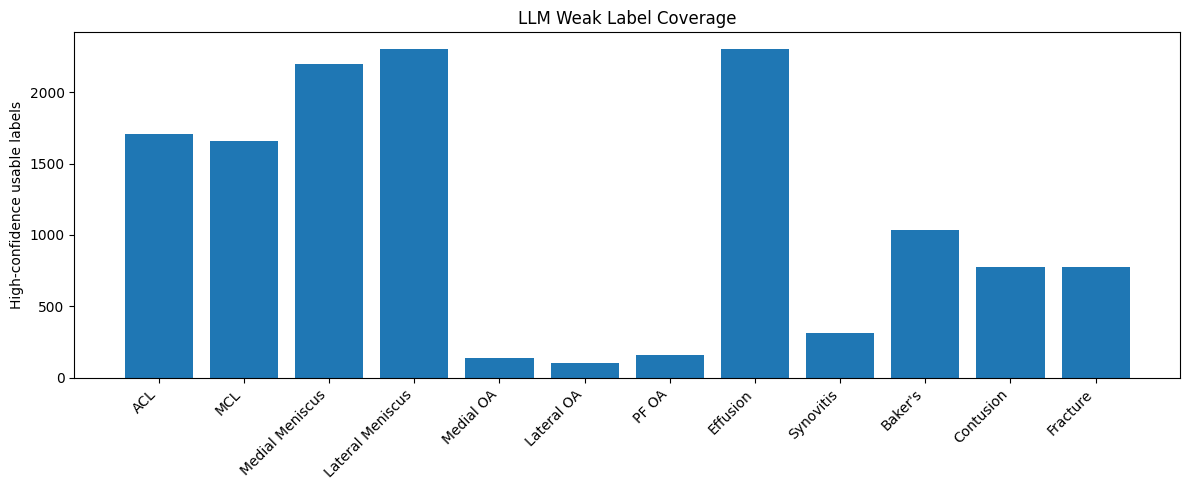

In [18]:
coverage = []

for col in label_cols:
    status_col = col + "_status"
    weak_col = col + "_weak"
    conf_col = col + "_confidence"

    row = {
        "Finding": col,
        "Present": int((weak_labels[status_col] == "Present").sum()),
        "Absent": int((weak_labels[status_col] == "Absent").sum()),
        "Uncertain": int((weak_labels[status_col] == "Uncertain").sum()),
        "Not_Mentioned": int((weak_labels[status_col] == "Not Mentioned").sum()),
        "High_Confidence_Usable": int((weak_labels[weak_col].notna() & (weak_labels[conf_col] >= 0.70)).sum())
    }
    coverage.append(row)

coverage_df = pd.DataFrame(coverage)
display(coverage_df)

plt.figure(figsize=(12, 5))
plt.bar(coverage_df["Finding"], coverage_df["High_Confidence_Usable"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("High-confidence usable labels")
plt.title("LLM Weak Label Coverage")
plt.tight_layout()
plt.show()

In [19]:
out_path = WORK_DIR + "/report_weak_labels_clean.csv"
validation_path = WORK_DIR + "/report_teacher_validation.csv"
coverage_path = WORK_DIR + "/report_teacher_coverage.csv"

weak_labels.to_csv(out_path, index=False)
teacher_validation.to_csv(validation_path, index=False)
coverage_df.to_csv(coverage_path, index=False)

print("Saved:", out_path)
print("Saved:", validation_path)
print("Saved:", coverage_path)

Saved: /kaggle/working/report_weak_labels_clean.csv
Saved: /kaggle/working/report_teacher_validation.csv
Saved: /kaggle/working/report_teacher_coverage.csv


## Report Note

This notebook implements the final report-teacher schema with explicit `Present`, `Absent`, `Uncertain`, and `Not Mentioned` states. Validation results from partial/smoke-test coverage should not be reported as final LLM accuracy. Fold-safe weak-supervision training should ensure held-out gold studies are not used for training labels in their validation fold.